In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
! unzip /content/archive.zip -d /content/dataset_yolo

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_yolo/train/5/00005_00053_00010.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00011.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00012.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00013.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00014.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00015.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00016.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00017.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00018.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00019.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00020.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00021.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00022.png  
  inflating: /content/dataset_yolo/train/5/00005_00053_00023.png  
  inflating

In [16]:
import pandas as pd
import os
import shutil
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
CSV_PATH = '/content/dataset_yolo/Train.csv'  # Path to your spreadsheet
IMAGE_ROOT = '/content/dataset_yolo/'           # The folder where your 'Train/' folder is located
OUTPUT_DIR = '/content/data'
TRAIN_RATIO = 0.8           # 80% training, 20% validation

# Create folder structure
for split in ['train', 'val']:
    os.makedirs(f'{OUTPUT_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/labels/{split}', exist_ok=True)

# Load data
df = pd.read_csv(CSV_PATH)

# IMPORTANT: Correct the image paths in the DataFrame for case sensitivity
# The unzipped folder is 'train' (lowercase), but CSV paths might be 'Train' (uppercase)
df['Path'] = df['Path'].apply(lambda x: x.replace('Train/', 'train/'))

# Split the unique image paths to ensure all boxes for one image stay together
unique_images = df['Path'].unique()
train_imgs, val_imgs = train_test_split(unique_images, train_size=TRAIN_RATIO)

def process_set(image_paths, split_name):
    for img_path in image_paths:
        # Get all rows for this specific image
        img_data = df[df['Path'] == img_path]

        # 1. Move/Copy Image
        src_path = os.path.join(IMAGE_ROOT, img_path)
        img_filename = os.path.basename(img_path)
        dest_path = f'{OUTPUT_DIR}/images/{split_name}/{img_filename}'

        if os.path.exists(src_path):
            try:
                shutil.copy(src_path, dest_path)
            except OSError as e:
                print(f"Error copying {src_path} to {dest_path}: {e}")
                print("This often indicates a temporary issue with Google Drive connectivity. Consider restarting the runtime and remounting Google Drive if this persists.")
                continue # Skip this file and try to continue with others
        else:
            print(f"Warning: Image not found at {src_path}")
            continue

        # 2. Create YOLO Label File (.txt)
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = f'{OUTPUT_DIR}/labels/{split_name}/{label_filename}'

        with open(label_path, 'w') as f:
            for _, row in img_data.iterrows():
                # Normalization
                dw = 1.0 / row['Width']
                dh = 1.0 / row['Height']

                x_center = (row['Roi.X1'] + row['Roi.X2']) / 2.0 * dw
                y_center = (row['Roi.Y1'] + row['Roi.Y2']) / 2.0 * dh
                w = (row['Roi.X2'] - row['Roi.X1']) * dw
                h = (row['Roi.Y2'] - row['Roi.Y1']) * dh

                # Write: class x_center y_center width height
                f.write(f"{int(row['ClassId'])} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# Run processing
process_set(train_imgs, 'train')
process_set(val_imgs, 'val')

print(f"Dataset ready in: {OUTPUT_DIR}")

Dataset ready in: /content/data


In [5]:
!touch data1.yaml

In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt') # load a pretrained model


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
results = model.train(data="data.yaml", epochs=20, imgsz=640)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

In [30]:
from ultralytics import YOLO

# Load your custom trained model
model1 = YOLO('/content/runs/detect/train/weights/best.pt')

# Run inference with save_crop=True
results = model1.predict(source='/content/00006.png', save_crop=True)


image 1/1 /content/00006.png: 576x640 1 18', 17.6ms
Speed: 10.2ms preprocess, 17.6ms inference, 1.8ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/runs/detect/predict5


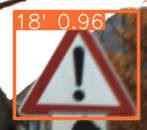

In [31]:
# Getting the result:
results[0].show()

In [25]:
results[0].save_crop(save_dir='my_crops')

In [33]:
import cv2
import os
from ultralytics import YOLO

# Load your model
model = YOLO('/content/runs/detect/train/weights/best.pt')
# Define source image path
source = '/content/00006.png'
# Read the image using OpenCV
img = cv2.imread(source)

results = model.predict(source)

save_dir = 'cropped_objects'
os.makedirs(save_dir, exist_ok=True)

if results[0].boxes is not None:
    for i, box in enumerate(results[0].boxes.xyxy):
        # Convert coordinates to integers
        x1, y1, x2, y2 = map(int, box[:4])

        # Crop the image using slicing [y_min:y_max, x_min:x_max]
        crop_img = img[y1:y2, x1:x2]

        # Save the cropped image
        crop_path = os.path.join(save_dir, f'crop_{i}.jpg')
        cv2.imwrite(crop_path, crop_img)
        print(f'Saved {crop_path}')
else:
    print("No objects detected.")


image 1/1 /content/00006.png: 576x640 1 18', 8.9ms
Speed: 2.0ms preprocess, 8.9ms inference, 1.2ms postprocess per image at shape (1, 3, 576, 640)
Saved cropped_objects/crop_0.jpg


# Object detection samples images:

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:00


In [4]:
# library:
import cv2
import os
from ultralytics import YOLO


image 1/1 /content/00001.png: 640x608 1 1, 296.8ms
Speed: 5.7ms preprocess, 296.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 608)


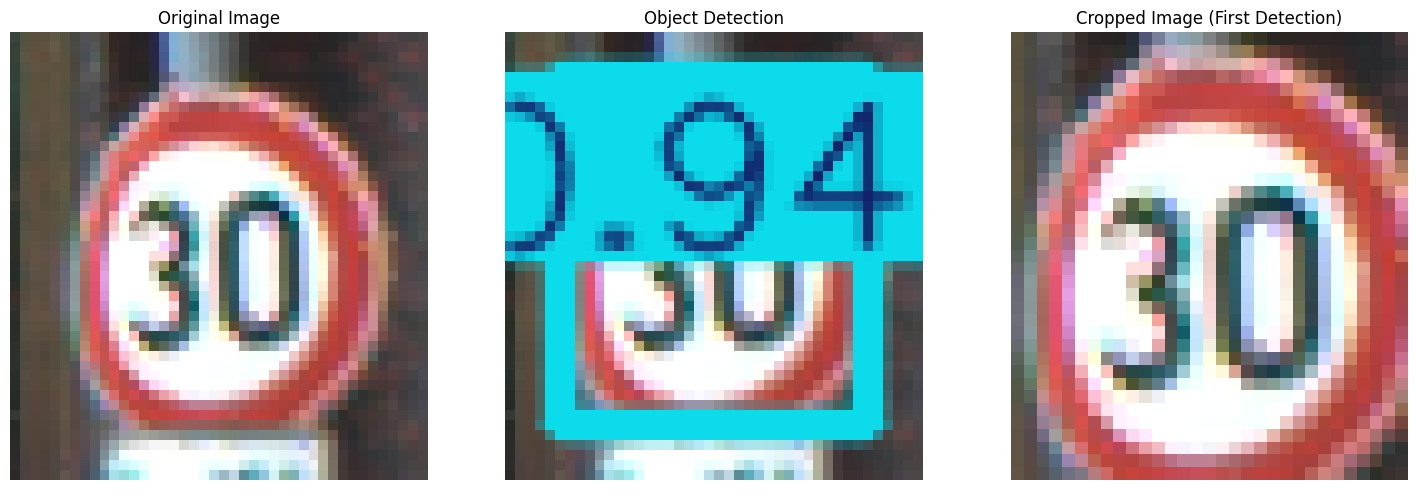


image 1/1 /content/00006.png: 576x640 1 18', 258.1ms
Speed: 5.8ms preprocess, 258.1ms inference, 1.2ms postprocess per image at shape (1, 3, 576, 640)


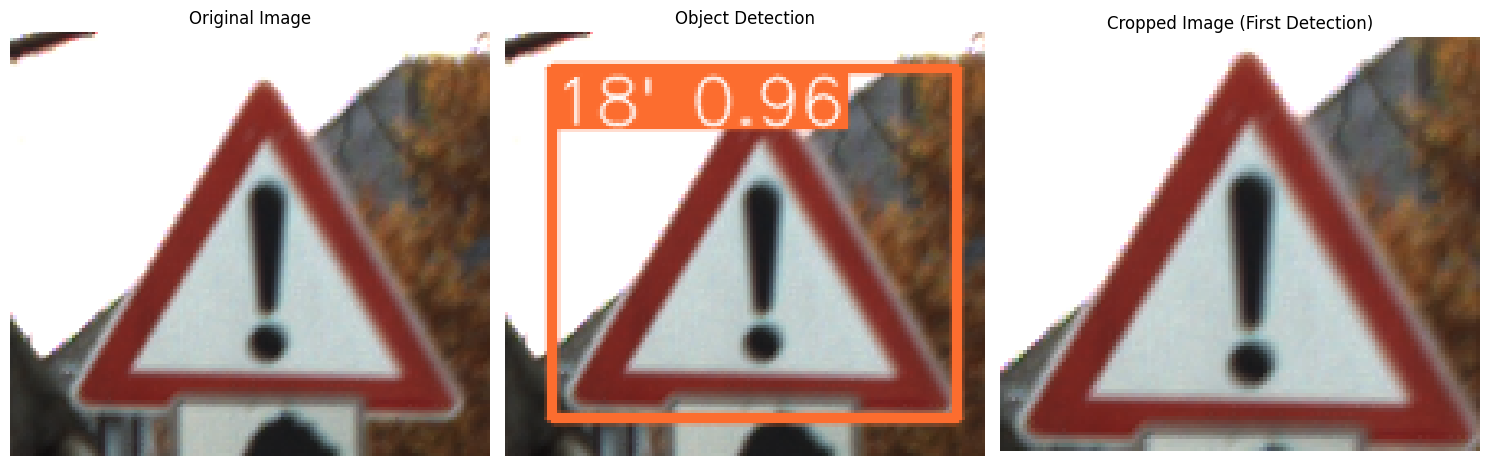


image 1/1 /content/00035.png: 640x640 1 17, 195.3ms
Speed: 6.1ms preprocess, 195.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


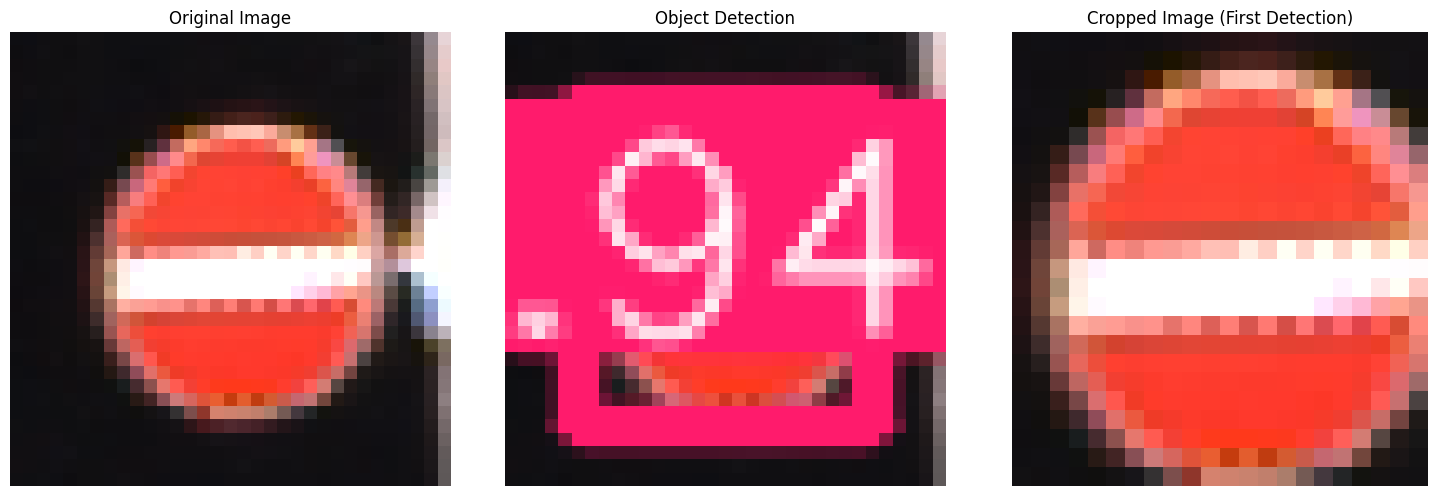


image 1/1 /content/00062.png: 640x640 1 4, 194.7ms
Speed: 5.1ms preprocess, 194.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


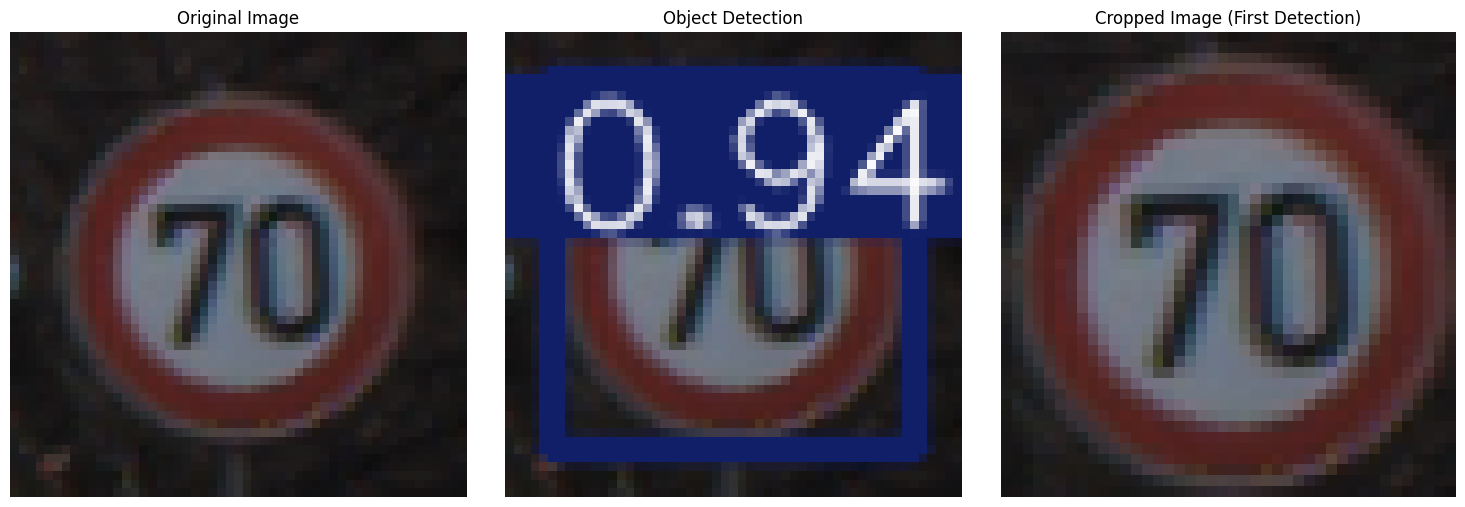


image 1/1 /content/00051.png: 608x640 1 13, 199.2ms
Speed: 6.4ms preprocess, 199.2ms inference, 0.9ms postprocess per image at shape (1, 3, 608, 640)


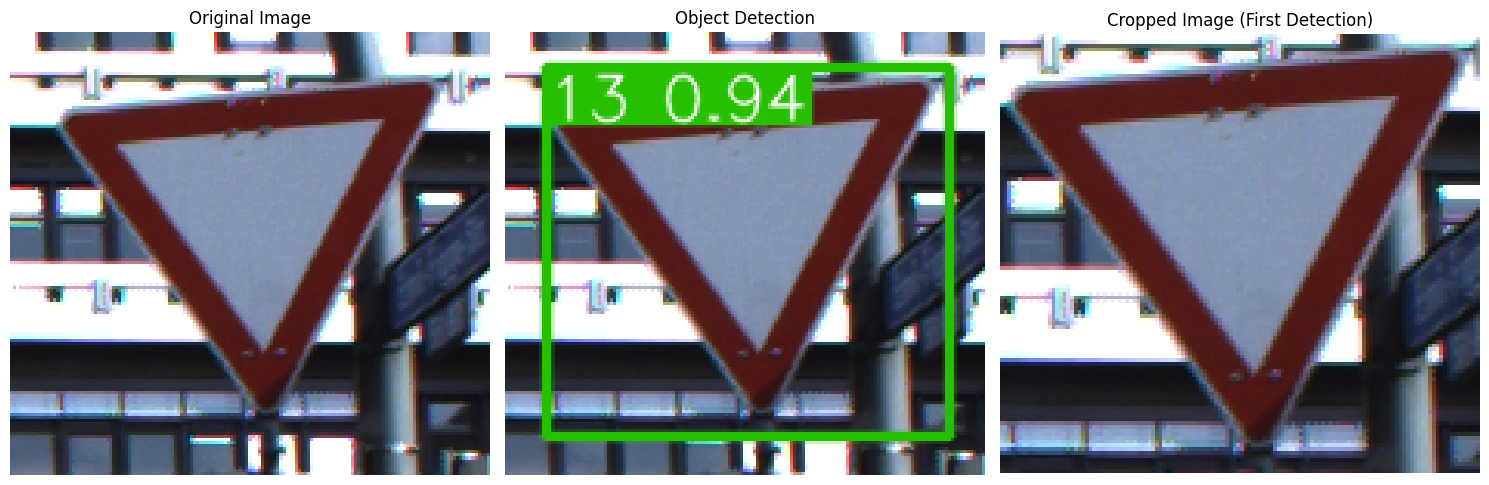


image 1/1 /content/00021.png: 640x608 1 33, 205.4ms
Speed: 6.3ms preprocess, 205.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 608)


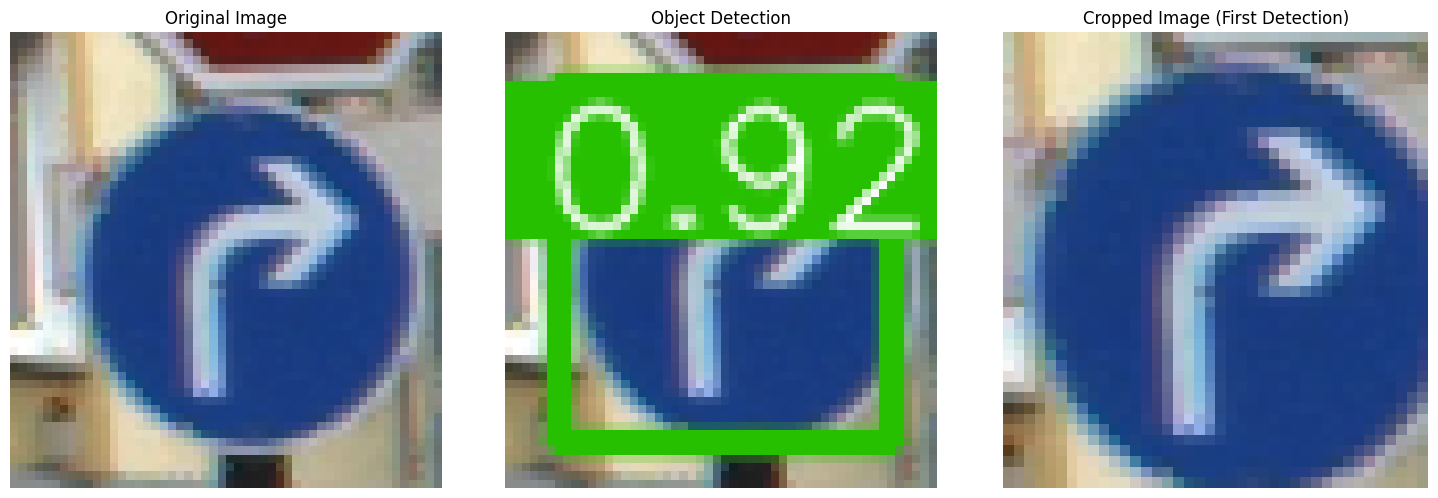


image 1/1 /content/00130.png: 640x640 1 36, 203.9ms
Speed: 6.9ms preprocess, 203.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


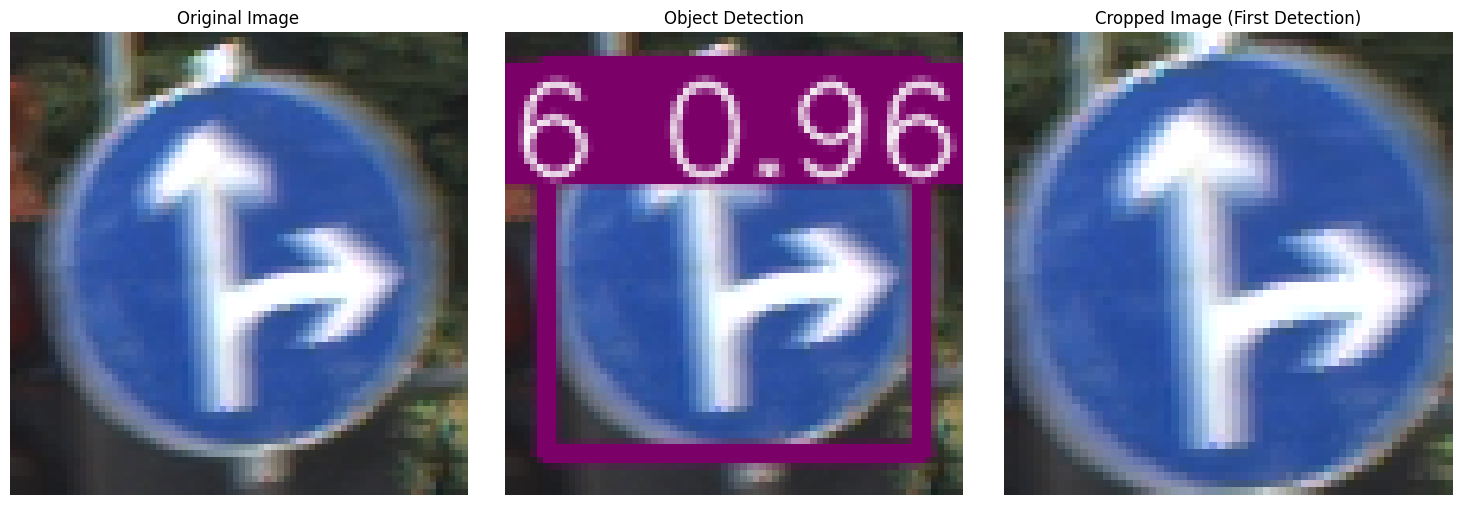


image 1/1 /content/00094.png: 640x640 1 12, 192.9ms
Speed: 7.1ms preprocess, 192.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


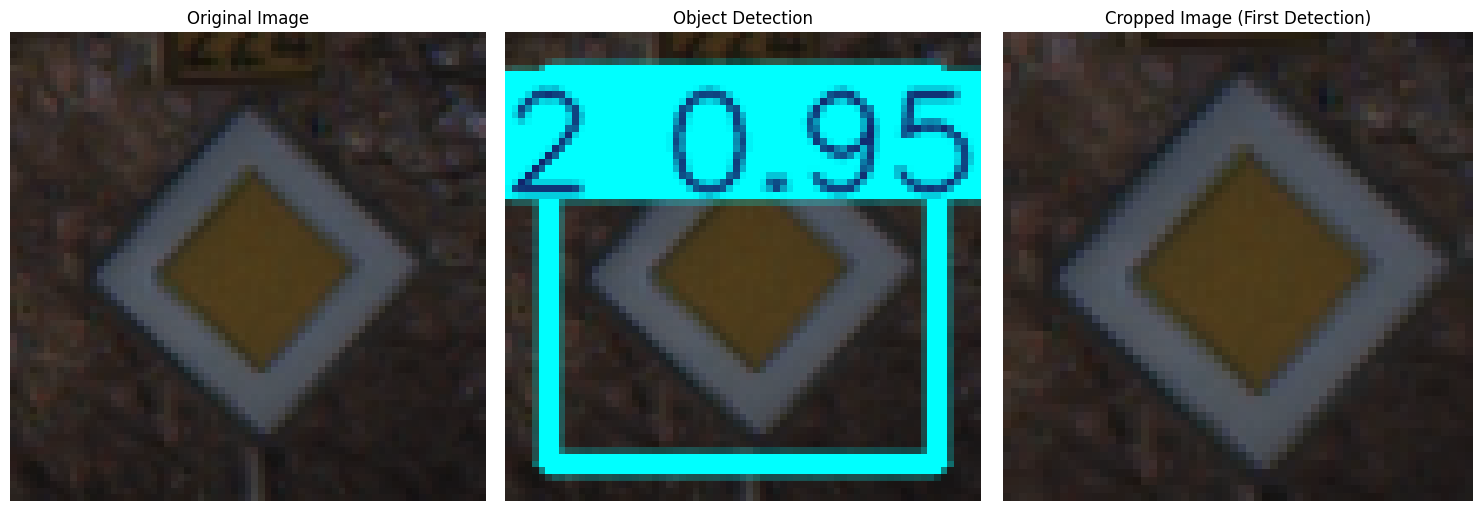


image 1/1 /content/00224.png: 640x640 1 14, 201.0ms
Speed: 7.3ms preprocess, 201.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


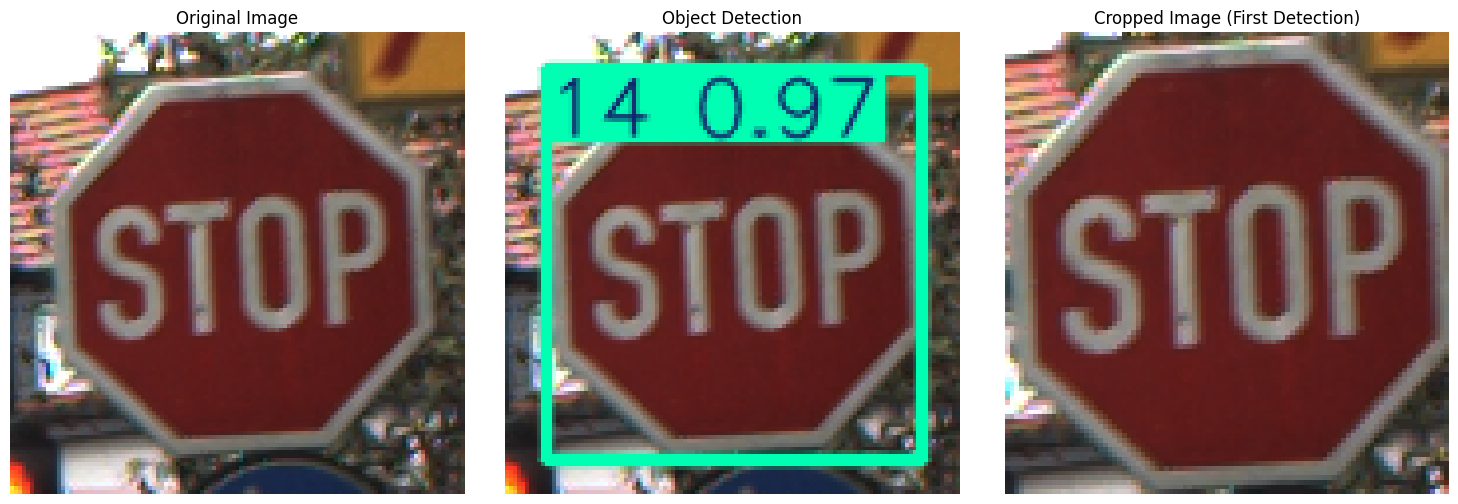

In [13]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

#  Load the YOLO model
model = YOLO('/content/yolo_object_detion_final_model.pt')
list1 = ['/content/00001.png', '/content/00006.png', '/content/00035.png', '/content/00062.png',
         '/content/00051.png', '/content/00021.png', '/content/00130.png', '/content/00094.png',
         '/content/00224.png']
for image_path in list1:
  #  Load the original image using OpenCV
  image_path = image_path
  original_image = cv2.imread(image_path)

  # OpenCV loads in BGR, Matplotlib expects RGB
  original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

  # model prediction
  results = model(image_path)


  annotated_image = results[0].plot()
  # Convert annotated image from BGR to RGB for Matplotlib
  annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)


  cropped_image_rgb = None
  if len(results[0].boxes) > 0:

      # Get the bounding box coordinates (xyxy format)
      box = results[0].boxes[0]
      # Convert the tensor to a list of integers
      x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
      # Crop the image using numpy slicing (roi = Region of Interest)
      roi = original_image[y1:y2, x1:x2]
      cropped_image_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
  else:
      # Create a blank image or handle case with no detections
      cropped_image_rgb = np.zeros_like(original_image_rgb)

  #  Display the images side by side using Matplotlib
  fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 1 row, 3 columns

  # Plot the original image
  axes[0].imshow(original_image_rgb)
  axes[0].set_title('Original Image')
  axes[0].axis('off') # Hide axis ticks

  # Plot the object detection image
  axes[1].imshow(annotated_image_rgb)
  axes[1].set_title('Object Detection')
  axes[1].axis('off')

  # Plot the cropped image
  axes[2].imshow(cropped_image_rgb)
  axes[2].set_title('Cropped Image (First Detection)')
  axes[2].axis('off')

  plt.tight_layout() # Adjust subplot params for specified padding
  plt.show()